### Load predictions

### - **Prerequisites**: verify/update `predictions_pathfile` and `predictions_raw_pathfile` so they point to your `predictions.csv` and `predictions_raw.csv`. To be filled with predictions created with the command line `uv run predict_phage_display`.

### ⚠️ **Note:** Due to licensing restrictions, we cannot provide the original train and test datasets used in the referenced paper. Instead, this notebook uses publicly available datasets that may not perfectly align with the model's requirements. The primary goal here is to offer a practical template for testing and understanding the model's workflow, rather than to produce benchmark-quality results. Please adapt paths and data handling to your own project as necessary.

In [131]:
import functools
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats


#TO BE CHANGED WITH YOUR PATH
predictions_pathfile = "results/experiments/example_prediction/predictions.csv"
predictions_raw_pathfile = "results/experiments/example_prediction/predictions_raw.csv"
selection_pathfile = "data/test_prediction.csv"

#get parent directory before notebook
parent_dir = os.getcwd().replace("notebook", "")

#relative path to the predictions.csv file
prediction_path = os.path.join(parent_dir, predictions_pathfile)

prediction_raw_path = os.path.join(parent_dir, predictions_raw_pathfile)

selection_path = os.path.join(parent_dir, selection_pathfile)

#load the predictions as a pandas dataframe
predictions = pd.read_csv(prediction_path)

#load the predictions_raw as a pandas dataframe
data_raw = pd.read_csv(prediction_raw_path)

#load the selection as a pandas dataframe
selection = pd.read_csv(selection_path)

#merge on sequence
predictions = predictions.merge(selection, on='sequence', how='left')



predictions['selectivities'] = (predictions['selected_count'] / predictions['selected_total']  ) / ( predictions['initial_count'] / predictions['initial_total'] )

predictions['selectivities_error'] = (1/np.sqrt(predictions['selected_count']) + 1/np.sqrt(predictions['initial_count'])) * predictions['selectivities']
predictions

,sequence,prediction_mean,prediction_std,prediction_neg_mean,prediction_neg_std,prediction_target_mean,prediction_target_std,auc_mean,ma_mean,experiment,initial_count,selected_count,initial_total,selected_total,selectivities,selectivities_error
0,PAMAEIRLDQSSAVVKRPGESVKISCKINGLDMTAHYMHWIRQKPG...,0.004186,0.013535,0.0,0.0,0.0,0.0,0.579379,0.271713,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
1,PAMAEIRLDQSSAVVKRPGESVKISCKINGLDMTAHYMHWIRQKPG...,0.006222,0.020430,0.0,0.0,0.0,0.0,0.470062,0.178343,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
2,PAMASQTLIESDSVIIKPDQSHKLTCTASGFNFGGSWMAWIRQSPG...,0.035996,0.037386,0.0,0.0,0.0,0.0,0.413416,0.138271,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
3,PAMASQTLIESDSVIIKPDQSHKLTCTASGFNFGGSWMAWIRQSPG...,0.045984,0.061082,0.0,0.0,0.0,0.0,0.520000,0.262420,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
4,PAMASQTLIESDSVIIKPDQSHKLTCTASGFNFGGSWMAWIRQSPG...,0.009917,0.020771,0.0,0.0,0.0,0.0,0.394037,0.169272,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,PAMAAVELTQVTSVMLKPGDSLTLSCKVSGYSVTDNSYATAWIRQP...,0.011413,0.019338,0.0,0.0,0.0,0.0,0.490186,0.196235,Mix24_DNA_2_3,1,0,13954,9893,0.000000,NaN
730,PAMAAVELTQVTSVMLKPGDSLTLSCKVSGYSVTDNSYATAWIRQP...,0.005921,0.011271,0.0,0.0,0.0,0.0,0.521491,0.200354,Mix24_DNA_2_3,1,0,13954,9893,0.000000,NaN
731,PAMAAVELTQVTSVMLKPGDSLTLSCKVSGYSVTDNSYATAWIRQP...,0.012654,0.021206,0.0,0.0,0.0,0.0,0.462857,0.193227,Mix24_DNA_2_3,1,0,13954,9893,0.000000,NaN
732,PAMAAVELTQVTSVMLKPGDSLTLSCKVSGYSVTDNSYATAWIRQP...,0.020578,0.034161,0.0,0.0,0.0,0.0,0.556025,0.308134,Mix24_DNA_2_3,1,0,13954,9893,0.000000,NaN


In [ ]:
# Take a random subset of the dataframe

#DELETE THIS CELL IF YOU ARE NOT USING EXAMPLE DATASET

predictions = predictions[(predictions['selectivities'] > 0) & (predictions['selectivities'] < 1e2)]
predictions = predictions[predictions['prediction_mean'] > 5*1e-2]

predictions = predictions.sample(frac=0.3, random_state=27)


,sequence,prediction_mean,prediction_std,prediction_neg_mean,prediction_neg_std,prediction_target_mean,prediction_target_std,auc_mean,ma_mean,experiment,initial_count,selected_count,initial_total,selected_total,selectivities,selectivities_error
100,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.148828,0.097208,0.0,0.0,0.0,0.0,0.579627,0.253540,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
564,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.325093,0.121969,0.0,0.0,0.0,0.0,0.541615,0.283400,Mix24_DNA_2_3,1,1,13954,9893,1.410492,2.820985
461,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.701955,0.215333,0.0,0.0,0.0,0.0,0.542857,0.337620,Mix24_DNA_2_3,2,1,13954,9893,0.705246,1.203930
406,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.214123,0.141113,0.0,0.0,0.0,0.0,0.595528,0.239528,Mix24_DNA_2_3,1,4,13954,9893,5.641969,8.462954
272,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.509582,0.189650,0.0,0.0,0.0,0.0,0.477019,0.211034,Mix24_DNA_2_3,2,2,13954,9893,1.410492,1.994737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.283903,0.152100,0.0,0.0,0.0,0.0,0.471304,0.145834,Mix24_DNA_2_3,9,2,13954,9893,0.313443,0.326118
286,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.296429,0.125484,0.0,0.0,0.0,0.0,0.490932,0.141369,Mix24_DNA_2_3,16,2,13954,9893,0.176312,0.168749
572,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.413208,0.167737,0.0,0.0,0.0,0.0,0.490435,0.168565,Mix24_DNA_2_3,2,3,13954,9893,2.115738,2.717575
266,PAMAQLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQP...,0.266964,0.117585,0.0,0.0,0.0,0.0,0.625590,0.244131,Mix24_DNA_2_3,17,5,13954,9893,0.414851,0.286143


### Simulate KD values for demonstration

- **Why**: real KD measurements that we used in our Paper are not public, so here we simulate values to illustrate the visualization.
- **What the next cell does**:
  - Fixes randomness (`np.random.seed(42)`).
  - Generates a fake spearman correlation around -0.40.


In [133]:
import numpy as np
import pandas as pd

def kd_from_normal_scaled(selectivity, error, kd_min=1e-12, kd_max=1e-5, random_state=None, 
                          noise_factor=0.25, percentile_clip=(0.5, 99.5)):
    """
    Generate KD values with strong negative correlation to selectivity (robust to outliers).
    
    Strategy for better negative correlation:
      1) Robust normalization using percentiles instead of min/max (handles outliers)
      2) Create base inverse relationship: inv = 1 - normalized_selectivity
      3) Add controlled noise proportional to error, weighted by noise_factor
      4) Map to log10 KD space [kd_min, kd_max]
      
    Parameters:
      - noise_factor: controls how much error impacts KD variance (default 0.25 for realistic spread)
      - percentile_clip: tuple (low, high) percentiles for robust normalization (default (1, 99))
      - Higher noise_factor = more variance but weaker correlation
    """
    sel_is_series = isinstance(selectivity, pd.Series)
    idx = selectivity.index if sel_is_series else None
    s = np.asarray(selectivity, dtype=float)
    e = np.asarray(error, dtype=float)

    if s.shape != e.shape:
        raise ValueError("selectivity and error must have the same shape.")
    if np.any(e < 0):
        raise ValueError("error (std) must be non-negative.")

    rng = np.random.default_rng(random_state)
    
    # Robust normalization to [0,1] using percentiles (avoids outlier compression)
    s_low = np.nanpercentile(s, percentile_clip[0])
    s_high = np.nanpercentile(s, percentile_clip[1])
    
    if not np.isfinite(s_high - s_low) or (s_high <= s_low):
        s_norm = np.full_like(s, 0.5, dtype=float)
    else:
        # Normalize and clip to [0,1]
        s_norm = (s - s_low) / (s_high - s_low)
        s_norm = np.clip(s_norm, 0.0, 1.0)
    
    # Create inverse relationship (high selectivity -> low KD)
    # This is the main deterministic component
    inv_base = 1.0 - s_norm
    
    # Add controlled Gaussian noise scaled by error
    # Normalize error robustly
    e_normalized = e / (s_high - s_low + 1e-10)
    noise = rng.normal(loc=0, scale=e_normalized * noise_factor)
    
    # Combine: strong inverse relationship + small noise
    inv_final = inv_base + noise
    inv_final = np.clip(inv_final, 0.0, 1.0)
    
    # Map to log10 KD space [kd_min, kd_max]
    log_min, log_max = np.log10(kd_min), np.log10(kd_max)
    log_kd = log_min + inv_final * (log_max - log_min)
    kd = np.power(10.0, log_kd)

    return pd.Series(kd, index=idx) if sel_is_series else kd

predictions['KD (M)'] = kd_from_normal_scaled(
    selectivity=predictions['selectivities'],
    error=predictions['selectivities_error'],
    random_state=42
)

predictions['Name'] = 'placeholder'

### Visualization: binding probability vs KD (simplified plot)

- **Goal**: plot `prediction_mean` (y) against `KD (M)` (x) with optional error bars.

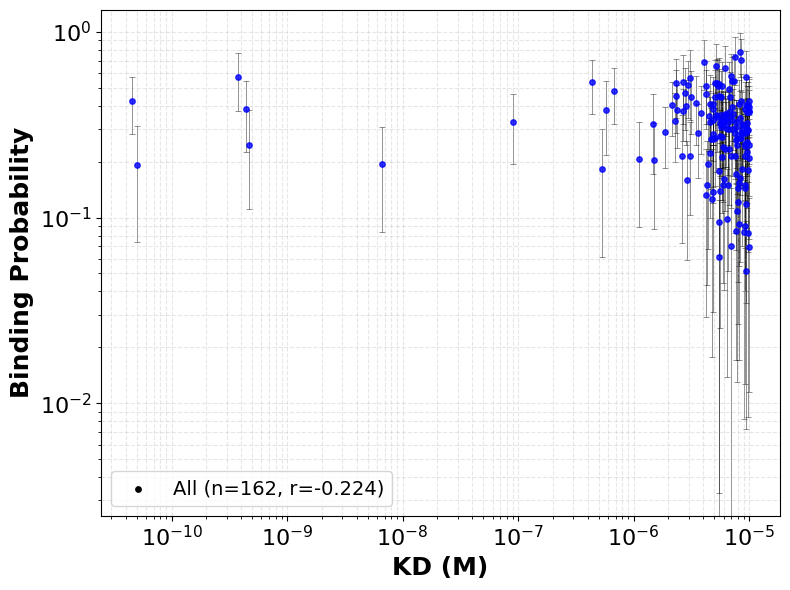

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

def plot_binding_selectivity_simple(
    x_axis,
    y_axis,
    ax,
    names,
    x_error=None,
    y_error=None,
    title_x="X-Axis",
    title_y="Y-Axis",
):
    """
    Plot binding probability (y) vs KD (x) on log-log axes with optional error bars.
    """
    x = np.asarray(x_axis)
    y = np.asarray(y_axis)
    names_arr = np.asarray(names)

    # Prepare error arrays (must be non-negative for Matplotlib)
    xerr = np.asarray(x_error) if x_error is not None else None
    yerr = np.asarray(y_error) if y_error is not None else None
    if xerr is not None:
        xerr = np.abs(xerr)
    if yerr is not None:
        yerr = np.abs(yerr)

    # Filter invalid/non-positive values for log-scale + NaNs/Infs
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if xerr is not None:
        valid = valid & np.isfinite(xerr)
    if yerr is not None:
        valid = valid & np.isfinite(yerr)

    x = x[valid]
    y = y[valid]
    names_arr = names_arr[valid]
    if xerr is not None:
        xerr = xerr[valid]
    if yerr is not None:
        yerr = yerr[valid]

    # Identify BFN vs non-BFN after filtering
    mask_bfn = np.array(['BFN' in str(n) for n in names_arr])
    mask_non_bfn = ~mask_bfn

    r_all, p_all = spearmanr(x, y)
    r_bfn, p_bfn = spearmanr(x[mask_bfn], y[mask_bfn]) if mask_bfn.any() else (np.nan, np.nan)
    r_non, p_non = spearmanr(x[mask_non_bfn], y[mask_non_bfn]) if mask_non_bfn.any() else (np.nan, np.nan)

    # Error bars (optional)
    if (xerr is not None) or (yerr is not None):
        ax.errorbar(
            x, y,
            xerr=xerr, yerr=yerr,
            fmt='none', capsize=2, capthick=0.5,
            ecolor='black', elinewidth=0.5,
            alpha=0.6, zorder=1,
        )

    # Scatter
    ax.scatter(
        x[mask_non_bfn], y[mask_non_bfn],
        s=15, c='blue', alpha=0.8,
        zorder=2,
    )
    if mask_bfn.any():
        ax.scatter(
            x[mask_bfn], y[mask_bfn],
            s=15, c='red', alpha=0.8,
            zorder=2,
        )

    # Add an 'All' handle to legend via an invisible point
    ax.scatter([], [], c='black', s=15, label=f"All (n={len(x)}, r={np.nan_to_num(r_all, nan=np.nan):.3f})")

    # Axes and styling
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(title_x, fontsize=18, fontweight='bold')
    ax.set_ylabel(title_y, fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=14)
    ax.set_title("")
    ax.legend(loc='best', fontsize=14, frameon=True)
    ax.grid(True, which='both', ls='--', alpha=0.3)

fig, ax = plt.subplots(figsize=(8, 6))
plot_binding_selectivity_simple(
    y_axis=predictions['prediction_mean'],
    x_axis=predictions['KD (M)'],
    ax=ax,
    names=predictions['Name'],
    y_error=predictions['prediction_std'],
    title_x="KD (M)",
    title_y="Binding Probability",
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9435/2886770193.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm_r')
/tmp/ipykernel_9435/2886770193.py:125: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc1 = ax.scatter(k_list, correlations_standard_mean, c=colors_standard, s=80, edgecolor='k', marker='x', zorder=3)


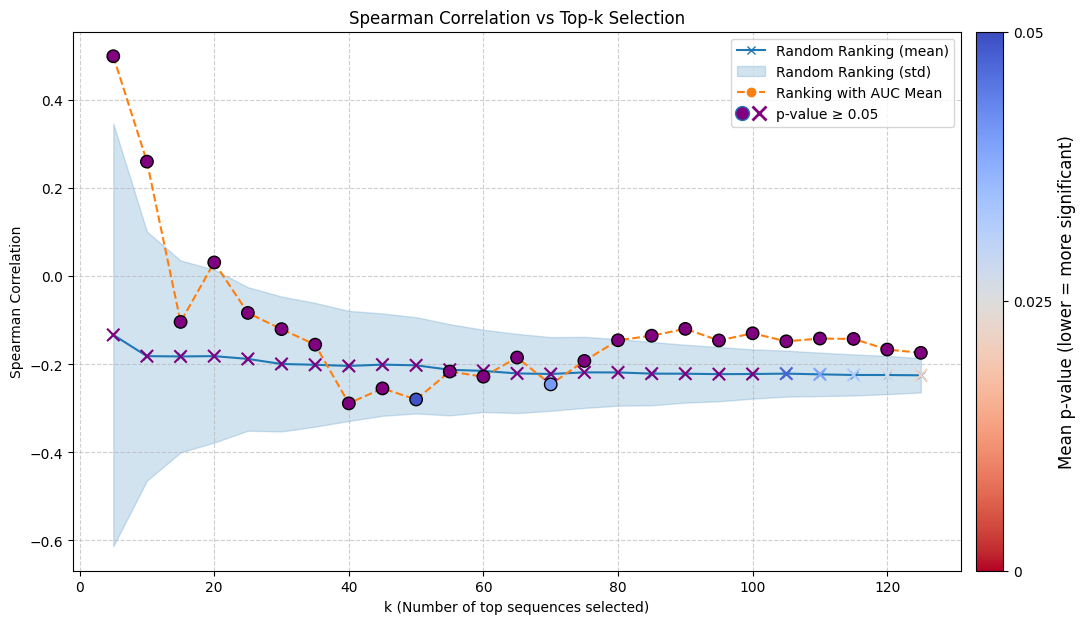

In [135]:
from typing import List

def plot_top_k_spearman_correlation(
    df: pd.DataFrame,
    k_list: List[int],
    true_value_col: str,
    pred_col: str,
    std_col: str,
    title: str = "Spearman Correlation vs Top-k Selection",
    n_samples: int = 100,
    ascending: bool = True
) -> None:
    """
    Plots Spearman correlation as a function of k, comparing a standard top-k
    ranking to one that prioritizes low uncertainty. For the standard ranking,
    performs n_samples random shuffles and plots the mean and std of the correlation.
    Also, colors the points according to the p-value (significance) of the correlation.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing true values, predictions, and standard deviations.
    k_list : List[int]
        A list of k values to plot (e.g., [10, 50, 100]).
    true_value_col : str
        The name of the column with true binding values (e.g., 'KD (M)').
    pred_col : str
        The name of the column with predicted binding means.
    std_col : str
        The name of the column with predicted standard deviations.
    title : str
        The title for the plot.
    n_samples : int
        Number of random shuffles to perform for the standard ranking.
    """

    import matplotlib.cm as cm

    # --- 1. Top-k Ranking based on Standard Prediction Score ---
    # For each sample, randomize the order of the dataframe and compute correlations
    correlations_standard_samples = []
    pvalues_standard_samples = []
    for sample_idx in range(n_samples):
        df_shuffled = df.sample(frac=1, random_state=sample_idx).reset_index(drop=True)
        correlations_this_sample = []
        pvalues_this_sample = []
        for k in k_list:
            top_k_df = df_shuffled.head(k)
            if len(top_k_df) < 2:
                correlations_this_sample.append(np.nan)
                pvalues_this_sample.append(np.nan)
                continue
            corr, pval = spearmanr(top_k_df[true_value_col], top_k_df[pred_col])
            correlations_this_sample.append(corr)
            pvalues_this_sample.append(pval)
        correlations_standard_samples.append(correlations_this_sample)
        pvalues_standard_samples.append(pvalues_this_sample)
    correlations_standard_samples = np.array(correlations_standard_samples)  # shape: (n_samples, len(k_list))
    pvalues_standard_samples = np.array(pvalues_standard_samples)
    correlations_standard_mean = np.nanmean(correlations_standard_samples, axis=0)
    correlations_standard_std = np.nanstd(correlations_standard_samples, axis=0)
    pvalues_standard_mean = np.nanmean(pvalues_standard_samples, axis=0)

    # --- 2. Top-k Ranking with Uncertainty-based Prioritization ---
    # Sort by uncertainty (std_col) ascending
    df_sorted_by_pred_and_uncertainty = df.sort_values(
        by=std_col, 
        ascending=ascending
    )
    correlations_uncertainty_ranked = []
    pvalues_uncertainty_ranked = []
    for k in k_list:
        top_k_df = df_sorted_by_pred_and_uncertainty.head(k)
        if len(top_k_df) < 2:
            correlations_uncertainty_ranked.append(np.nan)
            pvalues_uncertainty_ranked.append(np.nan)
            continue
        corr, pval = spearmanr(top_k_df[true_value_col], top_k_df[pred_col])
        correlations_uncertainty_ranked.append(corr)
        pvalues_uncertainty_ranked.append(pval)
    correlations_uncertainty_ranked = np.array(correlations_uncertainty_ranked)
    pvalues_uncertainty_ranked = np.array(pvalues_uncertainty_ranked)

    # --- 3. Plotting the Curves ---
    # Use explicit axes for colorbar
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, ax = plt.subplots(figsize=(12, 7))

    # For standard ranking, color points by p-value (smaller p = darker color)
    # We'll use a colormap that saturates at 0.05, and for p >= 0.05, use a distinct color (e.g., gray)
    norm = plt.Normalize(0, 0.05)
    cmap = cm.get_cmap('coolwarm_r')
    # For p >= 0.05, set to gray
    colors_standard = []
    for p in pvalues_standard_mean:
        if np.isnan(p):
            colors_standard.append((0.7, 0.7, 0.7, 1.0))
        elif p >= 0.05:
            #purple
            colors_standard.append((0.5, 0.0, 0.5, 1.0))
        else:
            colors_standard.append(cmap(norm(p)))
    # For uncertainty ranking, color points by p-value as well
    colors_uncertainty = []
    for p in pvalues_uncertainty_ranked:
        if np.isnan(p):
            colors_uncertainty.append((0.7, 0.7, 0.7, 1.0))
        elif p >= 0.05:
            #purple
            colors_uncertainty.append((0.5, 0.0, 0.5, 1.0))
        else:
            colors_uncertainty.append(cmap(norm(p)))

    # Plot mean and std for standard ranking
    ax.plot(k_list, correlations_standard_mean, marker='x', label='Random Ranking (mean)', color='C0')
    ax.fill_between(
        k_list,
        correlations_standard_mean - correlations_standard_std,
        correlations_standard_mean + correlations_standard_std,
        color='C0', alpha=0.2, label='Random Ranking (std)'
    )
    # Scatter points with color for p-value
    sc1 = ax.scatter(k_list, correlations_standard_mean, c=colors_standard, s=80, edgecolor='k', marker='x', zorder=3)

    # Plot uncertainty ranking
    ax.plot(k_list, correlations_uncertainty_ranked, marker='o', linestyle='--', label='Ranking with AUC Mean', color='C1')
    sc2 = ax.scatter(k_list, correlations_uncertainty_ranked, c=colors_uncertainty, s=80, marker='o', edgecolor='k', zorder=3)

    ax.set_xlabel('k (Number of top sequences selected)')
    ax.set_ylabel('Spearman Correlation')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add colorbar for p-value, using axes divider to ensure it attaches to ax
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, ticks=[0, 0.025, 0.05])
    cbar.set_label('Mean p-value (lower = more significant)', fontsize=12)
    cbar.ax.set_yticklabels(['0', '0.025', '0.05'])

    from matplotlib.lines import Line2D
    from matplotlib.legend_handler import HandlerTuple
    import matplotlib.patches as mpatches

    # --- Récupérer les handles et labels existants
    handles, labels = ax.get_legend_handles_labels()

    # --- Définir la couleur et créer les marqueurs personnalisés
    violet_color = (0.5, 0.0, 0.5, 1.0)

    # 1. On crée les deux marqueurs (sans ligne : linestyle='None')
    violet_circle = Line2D([0], [0], linestyle='None', marker='o',
                        markerfacecolor=violet_color, markersize=10)

    violet_cross = Line2D([0], [0], linestyle='None', marker='x',
                        color=violet_color, markersize=10, markeredgewidth=2)

    # --- Ajouter les marqueurs personnalisés à la légende ---
    handles.append((violet_circle, violet_cross))
    labels.append('p-value ≥ 0.05')
    ax.legend(handles=handles,
          labels=labels,
          loc='best',
          handler_map={tuple: HandlerTuple(ndivide=None)})

    plt.show()


k_list_to_plot = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125]

plot_top_k_spearman_correlation(
        df=predictions,
        k_list=k_list_to_plot,
        true_value_col='KD (M)',
        pred_col='prediction_mean',
        std_col='auc_mean',
        n_samples=100,
        ascending=False
    )

/tmp/ipykernel_9435/2886770193.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm_r')
/tmp/ipykernel_9435/2886770193.py:125: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc1 = ax.scatter(k_list, correlations_standard_mean, c=colors_standard, s=80, edgecolor='k', marker='x', zorder=3)


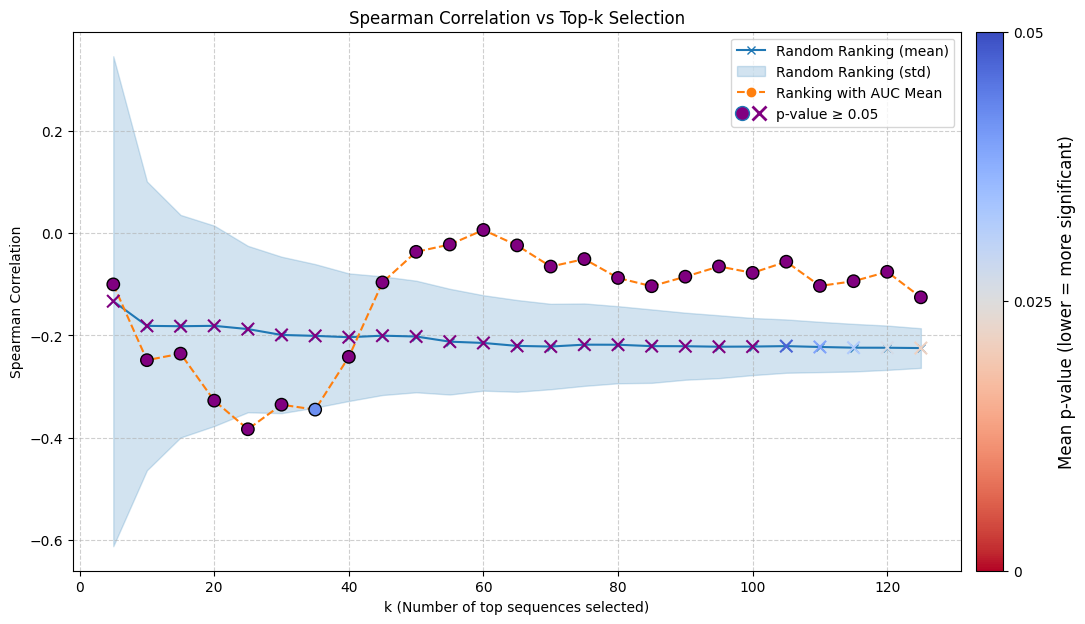

In [136]:
plot_top_k_spearman_correlation(
        df=predictions,
        k_list=k_list_to_plot,
        true_value_col='KD (M)',
        pred_col='prediction_mean',
        std_col='prediction_std',
        n_samples=100,
    )


### Binned correlation analysis (quick overview)

This section compares model predictions to measured binding using simple binning on uncertainty/error metrics.

- **Metrics binned**:
  - `Relative KD Error` = `KD Error / KD (M)`
  - `Relative Prediction Std Error` = `prediction_std / prediction_mean`
  - `AUC Mean` = `auc_mean`

- **Bin definitions**:
  - For a given metric, three bins are built from quantiles: `[0, q33)`, `[q33, q66)`, `[q66, q100]`.
  - The bin order matches the original notebook design:
    - `Relative KD Error`: low ➝ mid ➝ high
    - `Relative Prediction Std Error`: high ➝ mid ➝ low
    - `AUC Mean`: low ➝ mid ➝ high

- **Per-bin scatter plots**:
  - X-axis: `KD (M)` (log scale)
  - Y-axis: `Binding Probability` (`prediction_mean`, log scale)
  - Optional error bars: `KD Error` (x), `prediction_std` (y)
  - Annotation shows Spearman `r` and `p` computed within the bin, plus `N` in the title.
  - If a bin has fewer than 2 points, a message is shown instead of a plot.

- **Summary bar chart**:
  - Displays Spearman `r` for each bin (with annotations for `r`, `p`, and CI placeholder).

Notes:
- All masking and statistics are performed within each bin only.
- The last bin includes its upper bound; others exclude it, to avoid gaps.


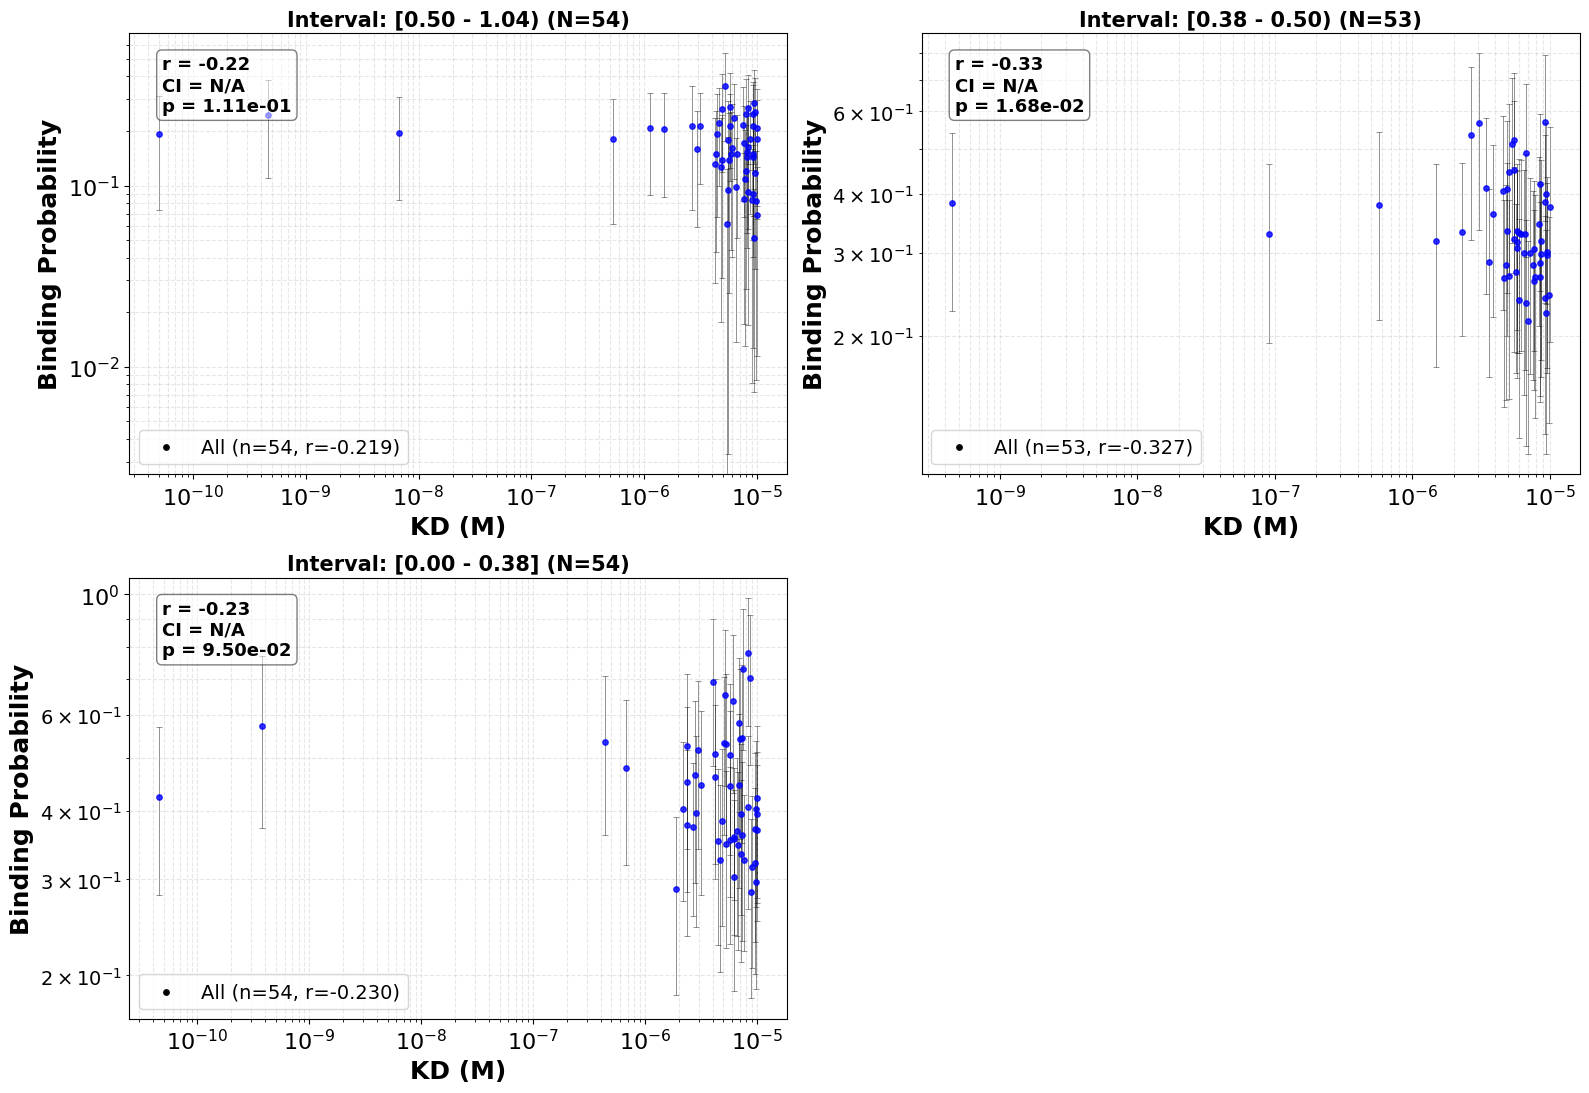

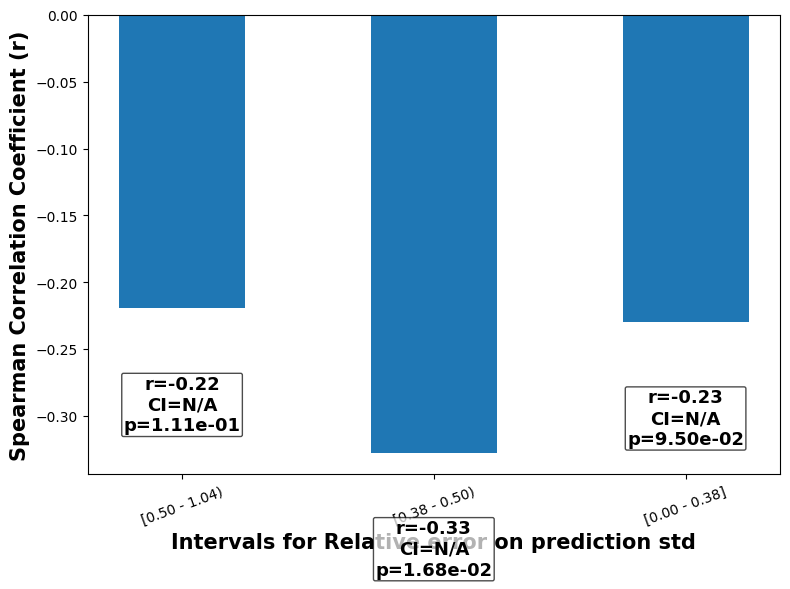

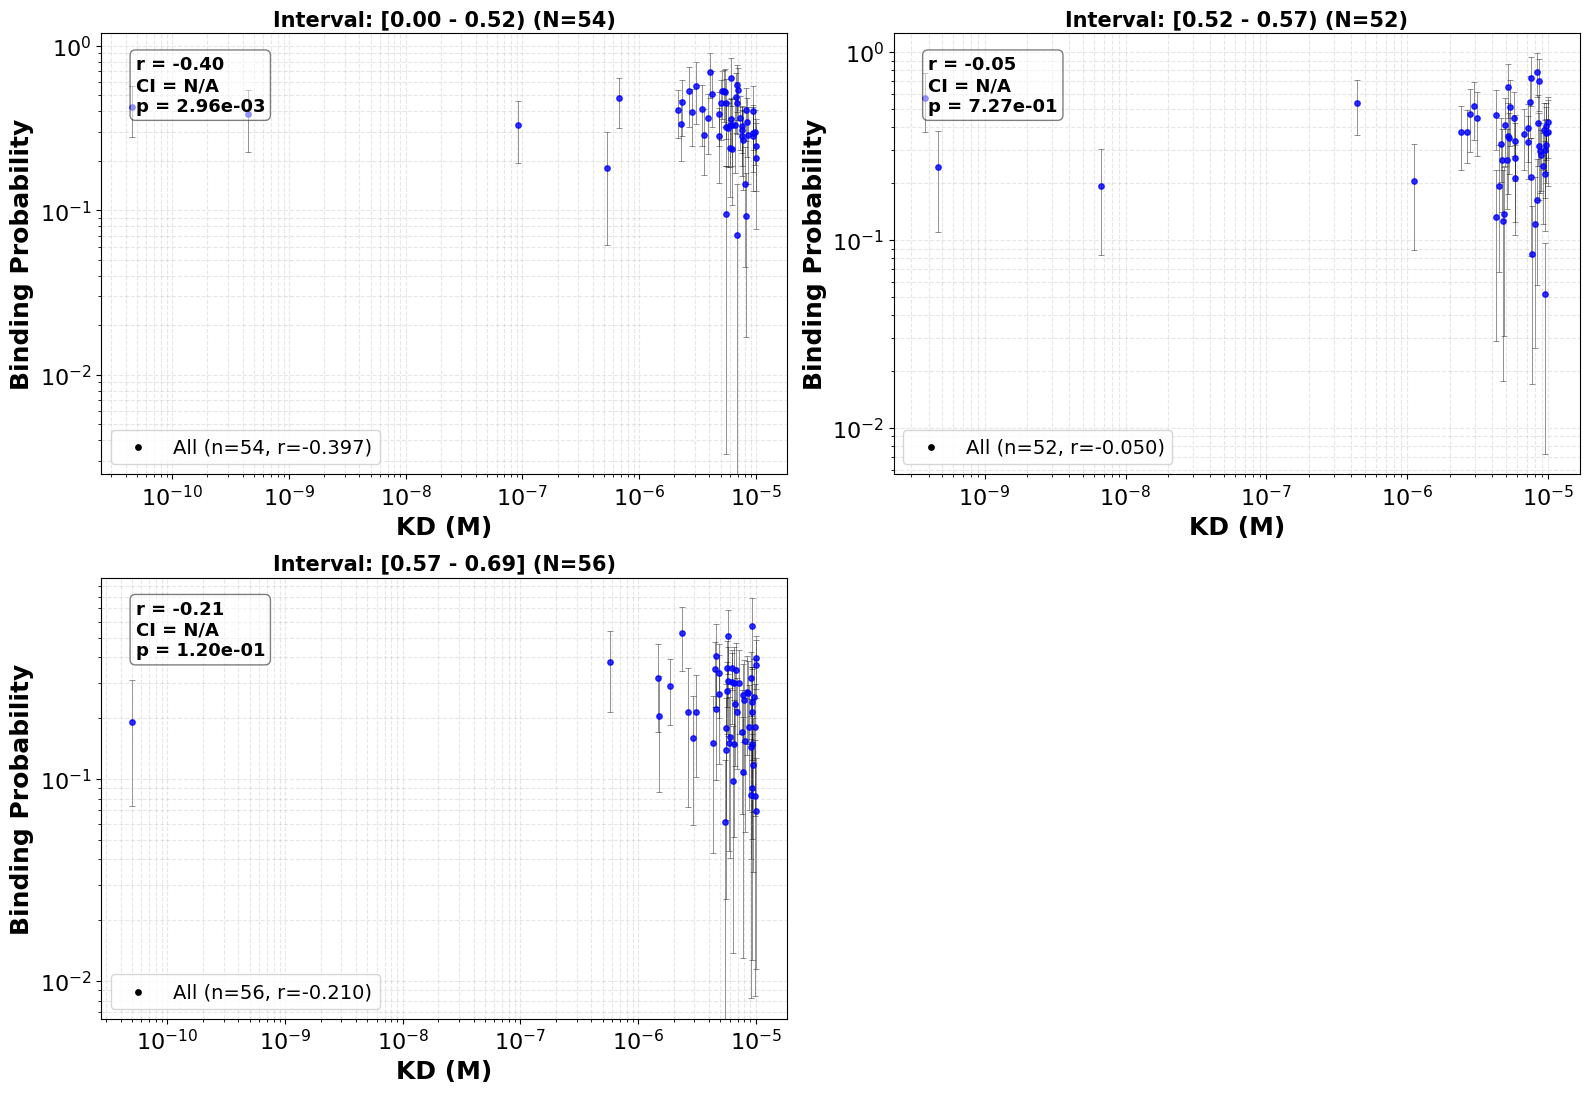

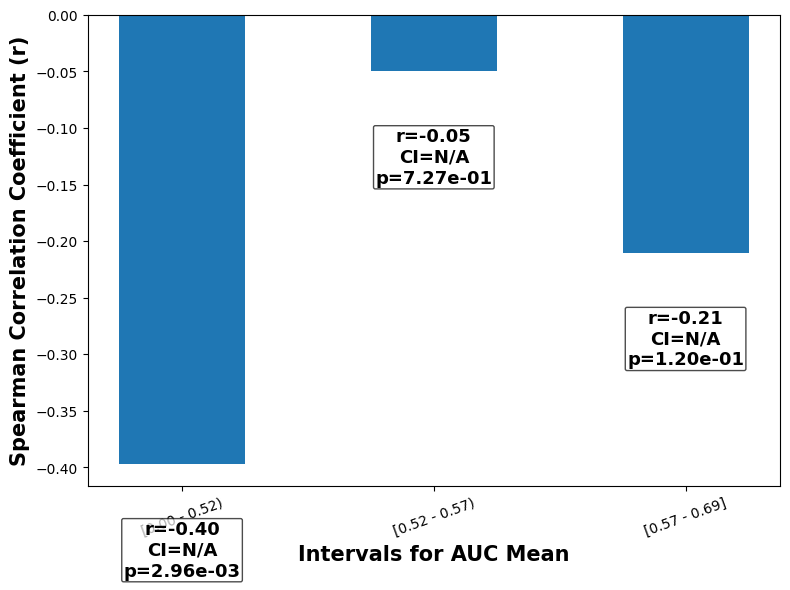

In [137]:
# Precompute relative error metrics
predictions['Relative Prediction Std Error'] = predictions['prediction_std'] / predictions['prediction_mean']
predictions['AUC Mean'] = predictions['auc_mean']

# Define bin configurations per metric (using quantiles)
# Keep the same bin ranges and order as the original notebook
error_type_configs = [

    {
        'name': 'Relative error on prediction std',
        'column': 'Relative Prediction Std Error',
        'bins': [
            (predictions['Relative Prediction Std Error'].quantile(0.66), predictions['Relative Prediction Std Error'].quantile(1)),
            (predictions['Relative Prediction Std Error'].quantile(0.33), predictions['Relative Prediction Std Error'].quantile(0.66)),
            (0.00, predictions['Relative Prediction Std Error'].quantile(0.33)),
        ]
    },
    {
        'name': 'AUC Mean',
        'column': 'AUC Mean',
        'bins': [
            (0.00, predictions['auc_mean'].quantile(0.33)),
            (predictions['auc_mean'].quantile(0.33), predictions['auc_mean'].quantile(0.66)),
            (predictions['auc_mean'].quantile(0.66), predictions['auc_mean'].quantile(1)),
        ]
    }
]

for config in error_type_configs:
    error_name = config['name']
    error_column = config['column']
    bins = config['bins']

    # Prepare the scatter grid
    num_plots = len(bins)
    num_cols = 2
    num_rows = (num_plots + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8 * num_cols, 6 * num_rows))
    axes = axes.flatten()

    correlation_results = []

    for i, (lower_bound, upper_bound) in enumerate(bins):
        ax = axes[i]

        # Build mask; last bin includes upper bound, others exclude upper bound
        is_last_bin = (i == len(bins) - 1)
        if is_last_bin:
            mask = (predictions[error_column] >= lower_bound) & (predictions[error_column] <= upper_bound)
        else:
            mask = (predictions[error_column] >= lower_bound) & (predictions[error_column] < upper_bound)

        # Apply mask to all series
        x_values = predictions.loc[mask, 'KD (M)'].values
        y_values = predictions.loc[mask, 'prediction_mean'].values
        names_values = predictions.loc[mask, 'Name'].values
        y_err = predictions.loc[mask, 'prediction_std'].values
        n_filtered = int(mask.sum())

        # Plot masked data only (guard if < 2 points to avoid errors inside the plotting helper)
        if n_filtered >= 2:
            plot_binding_selectivity_simple(
                y_axis=y_values,
                x_axis=x_values,
                ax=ax,
                names=names_values,
                y_error=y_err,
                title_x="KD (M)",
                title_y="Binding Probability",
            )
        else:
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.text(
                0.5, 0.5,
                'Insufficient data in this bin',
                transform=ax.transAxes,
                ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5)
            )

        # Spearman correlation on masked data
        r_val, p_val = (np.nan, np.nan)
        ci_str = "N/A"
        if n_filtered >= 2:
            r_val, p_val = spearmanr(x_values, y_values)

        # Annotate subplot
        ax.text(
            0.05, 0.95,
            f"r = {r_val:.2f}\nCI = {ci_str}\np = {p_val:.2e}",
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5),
            fontsize=13, fontweight='bold', wrap=True
        )

        # Save per-bin stats
        right_bracket = ']' if is_last_bin else ')'
        correlation_results.append({
            'bin_label': f'[{lower_bound:.2f} - {upper_bound:.2f}{right_bracket}',
            'r': r_val,
            'p': p_val,
            'n': n_filtered,
            'ci_str': ci_str
        })

        ax.set_title(
            f"Interval: [{lower_bound:.2f} - {upper_bound:.2f}{right_bracket} (N={n_filtered})",
            fontsize=15, fontweight='bold'
        )

    # Remove any unused axes if 3 plots on a 2x2 grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Summary bar chart of correlations per bin
    fig_corr, ax_corr = plt.subplots(figsize=(8, 6))

    labels = [res['bin_label'] for res in correlation_results]
    r_values = [res['r'] for res in correlation_results]

    bar_width = 0.2  
    bar_positions = np.arange(len(labels)) * 0.4
    bars = ax_corr.bar(bar_positions, r_values, width=bar_width)

    ax_corr.set_xticks(bar_positions)
    ax_corr.set_xticklabels(labels, rotation=20)

    for bar, result in zip(bars, correlation_results):
        yval = bar.get_height()
        text_offset = 0.05 if yval >= 0 else -0.05
        va = 'bottom' if yval >= 0 else 'top'
        annotation_text = (
            f"r={result['r']:.2f}\nCI={result['ci_str']}\np={result['p']:.2e}"
        )
        ax_corr.text(
            bar.get_x() + bar.get_width()/2.0, yval + text_offset,
            annotation_text,
            ha='center', va=va, fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7)
        )

    ax_corr.axhline(0, color='grey', linewidth=0.5)
    ax_corr.set_xlabel(f'Intervals for {error_name}', fontsize=15, fontweight='bold')
    ax_corr.set_ylabel('Spearman Correlation Coefficient (r)', fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.show()
